#Chile - Universidad Adolfo Ibáñez (UAI)
##Curso NLP
### Text Classification - Sentiment Analysis (Inglés)

# Carga & Exploración de Datos

In [1]:
#Importar Librerías
import pandas as pd
import numpy as np
import spacy

In [2]:
#Importar Archivos
df_train = pd.read_csv('/content/sentiment_analysis_train.csv', encoding='latin-1')
df_test = pd.read_csv('/content/sentiment_analysis_test.csv', encoding='latin-1')

In [3]:
#Verificar Columns
print("Train Dataset:", df_train.columns)
print("Test Dataset:", df_test.columns)

Train Dataset: Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')
Test Dataset: Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')


In [4]:
#Verificar Tamaño
print("Train Dataset:", df_train.shape)
print("Test Dataset:", df_test.shape)

Train Dataset: (5000, 6)
Test Dataset: (1000, 6)


In [5]:
#Verificar Contenido
df_train.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,44062,89014,"Washington, DC",13/04/2020,???What's happening livestock futures prices f...,Positive
1,44734,89686,"Tallahassee, FL.",14/04/2020,Despite the current economic slowdown caused b...,Positive
2,31094,76046,Kinross,03/04/2020,The has forced the 44 year old staff member in...,Positive
3,19512,64464,United Kingdom,22/03/2020,Covid-19 is causing difficulties across the en...,Negative
4,9308,54260,NaN,19/03/2020,Incomprehensible In a Lidl supermarket in a cu...,Negative


In [6]:
#Verificar Distribución Label (Train)
print("Label Distribution (Train)\n", df_train['Sentiment'].value_counts(normalize=True))

Label Distribution (Train)
 Sentiment
Positive    0.4330
Negative    0.3722
Neutral     0.1948
Name: proportion, dtype: float64


In [7]:
#Verificar Distribución Label (Test)
print("Label Distribution (Train)\n", df_test['Sentiment'].value_counts(normalize=True))

Label Distribution (Train)
 Sentiment
Negative    0.449
Positive    0.404
Neutral     0.147
Name: proportion, dtype: float64


# Representación Vectorial

In [8]:
#Descargar spaCy pipeline
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
#Cargar Pipeline
nlp = spacy.load("en_core_web_sm")

In [10]:
#Obtener Doc Word Embeddings (Train)
doc_vectors_train = list()
for tweet in df_train['OriginalTweet']:
  doc = nlp(tweet)
  doc_vectors_train.append(doc.vector)

In [11]:
#Obtener Doc Word Embeddings (Test)
doc_vectors_test = list()
for tweet in df_test['OriginalTweet']:
  doc = nlp(tweet)
  doc_vectors_test.append(doc.vector)

In [12]:
#Generar Matriz X
X_train = np.array(doc_vectors_train)
X_test = np.array(doc_vectors_test)
print("Dimensionalidad X Train:", X_train.shape)
print("Dimensionalidad X Test:", X_test.shape)

Dimensionalidad X Train: (5000, 96)
Dimensionalidad X Test: (1000, 96)


# Train, Dev & Test Set

In [13]:
#Importar Librerías
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [14]:
#Listado Ordeneado de Clases
classes = ['Negative',
           'Neutral',
           'Positive']

In [15]:
#Crear & Entrenar Objeto LabelBinarizer
lb = LabelBinarizer()
lb.fit(df_train['Sentiment'])

LabelBinarizer()

In [16]:
#Creación Vector Labels
y_train = lb.transform(df_train['Sentiment'])
y_test = lb.transform(df_test['Sentiment'])

In [17]:
#Creación Train & Dev Set
dev_size = 0.1
X_train_dev, X_dev, y_train_dev, y_dev = train_test_split(X_train, y_train,
                                                          test_size= dev_size,
                                                          random_state=0,
                                                          stratify = y_train)

In [18]:
#Validar Tamaño Datasets
print('Train-Dev Set: X', X_train_dev.shape, '- Y: ',y_train_dev.shape)
print('Dev Set: X', X_dev.shape, '- Y: ',y_dev.shape)
print('Test Set: X', X_test.shape, '- Y: ',y_test.shape)

Train-Dev Set: X (4500, 96) - Y:  (4500, 3)
Dev Set: X (500, 96) - Y:  (500, 3)
Test Set: X (1000, 96) - Y:  (1000, 3)


In [19]:
#Guardar Dimensiones de la Rep. Vectorial
input_dim = X_train_dev.shape[1]

# FNN (2 Layers) - Sin HP

In [20]:
#Importar Librerías
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import f1_score

In [21]:
#Creación & Configuración Objeto Sequential

#Inicializar Modelo
model_ann_2l = Sequential()

#Capa Entrada
model_ann_2l.add(Dense(96,input_dim = input_dim, activation = 'relu'))

#Primera Capa Oculta
model_ann_2l.add(Dense(96, activation = 'relu'))

#Capa Salida
model_ann_2l.add(Dense(3, activation = 'softmax'))

#Compilación
model_ann_2l.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_ann_2l.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,915 (73.89 KB)

 Trainable params: 18,915 (73.89 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#Entrenar ANN
history_ann_2l = model_ann_2l.fit(X_train, y_train,
                                  epochs=20,
                                  validation_split = 0.2,
                                  batch_size=5)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4400 - loss: 1.0392 - val_accuracy: 0.4930 - val_loss: 0.9768
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4747 - loss: 0.9942 - val_accuracy: 0.5030 - val_loss: 0.9612
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5101 - loss: 0.9574 - val_accuracy: 0.5130 - val_loss: 0.9459
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5363 - loss: 0.9286 - val_accuracy: 0.5120 - val_loss: 0.9603
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5611 - loss: 0.8991 - val_accuracy: 0.4880 - val_loss: 0.9605
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5791 - loss: 0.8691 - val_accuracy: 0.5000 - val_loss: 1.0017
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6114 - loss: 0.8350 - val_accuracy: 0.4900 - val_loss: 1.0657
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6418 - loss: 0.7812 - val_accuracy: 0.

In [23]:
#Gráfico Accuracy & Loss (Training & Validation)

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

def plot_accuracy_loss(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training Accuracy')
    plt.plot(x, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training Loss')
    plt.plot(x, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

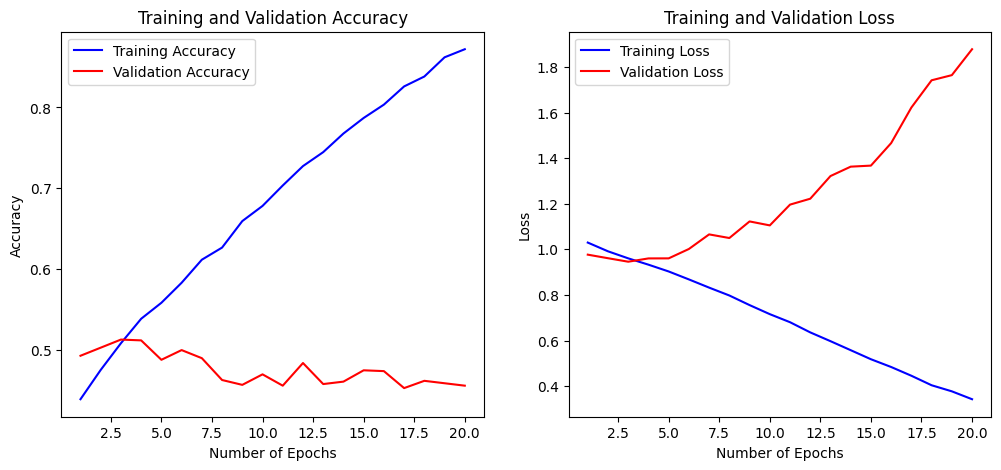

In [24]:
#Revisar Accuracy & Loss
plot_accuracy_loss(history_ann_2l)

In [25]:
#Umbral de Predicción
threshold = 0.5

In [26]:
#Evaluar ANN
y_pred_ann_2l = model_ann_2l.predict(X_test) > threshold

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [27]:
#Evaluación
print('F1 Score (Weighted)', round(f1_score(y_test, y_pred_ann_2l, average='weighted'),3))
print('F1 Score (por Clase)', f1_score(y_test, y_pred_ann_2l, average=None))

F1 Score (Weighted) 0.458
F1 Score (por Clase) [0.4617284  0.38255034 0.4803805 ]


# FNN (2 Layers) - Con HP

In [28]:
#Instalar e Importar Keras Turner
!pip install keras-tuner -q
import keras_tuner as kt
from keras.backend import clear_session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.9 MB/s eta 0:00:00


In [29]:
# Función para Creación Modelo

def ann_2l_model(hp):

  clear_session()

  #Inicializar Modelo
  model = Sequential()

  # HP para Función Activación
  hp_activation_function = hp.Choice('activation', ['relu', 'tanh'])

  # HP para Cantidad de Nodos en Capa Oculta
  hp_units = hp.Int('units', min_value = 80, max_value = 120, step = 10, default = 96)

  #Capa Entrada
  model.add(Dense(hp_units, input_dim = input_dim, activation = hp_activation_function))

  #Primera Capa Oculta
  model.add(Dense(hp_units, activation = hp_activation_function))

  #Capa Salida
  model.add(Dense(3, activation = 'softmax'))

  #Model Compilation
  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [30]:
#Inicializar Objeto Keras Turner
turner = kt.BayesianOptimization(hypermodel = ann_2l_model,
                                 objective=kt.Objective('val_accuracy', direction='max'),
                                 max_trials = 5,
                                 overwrite = True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
#Revisar Espacio de Búsqueda
turner.search_space_summary()

Search space summary
Default search space size: 2
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
units (Int)
{'default': 96, 'conditions': [], 'min_value': 80, 'max_value': 120, 'step': 10, 'sampling': 'linear'}


In [32]:
#Encontrar HP
turner.search(X_train_dev, y_train_dev,
              epochs = 10,
              validation_data = (X_dev, y_dev))

Trial 5 Complete [00h 00m 10s]
val_accuracy: 0.515999972820282

Best val_accuracy So Far: 0.5180000066757202
Total elapsed time: 00h 01m 00s


In [33]:
#Mejores HP
best_ann_2l_hp = turner.get_best_hyperparameters(1)[0]
print('\Mejores HP:', best_ann_2l_hp.values)

\Mejores HP: {'activation': 'relu', 'units': 120}


<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipython-input-4152915339.py:3: SyntaxWarning: invalid escape sequence '\M'
  print('\Mejores HP:', best_ann_2l_hp.values)


In [34]:
#Construir Modelo con Mejores HP
hp_model_ann_2l = turner.hypermodel.build(best_ann_2l_hp)
hp_model_ann_2l.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 120)            │        11,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │        14,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,523 (103.61 KB)

 Trainable params: 26,523 (103.61 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#Compilación
hp_model_ann_2l.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [36]:
#Entrenar ANN
history_hp_ann_2l = hp_model_ann_2l.fit(X_train, y_train,
                                        epochs=20,
                                        validation_split = 0.2,
                                        batch_size=5)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4163 - loss: 1.0516 - val_accuracy: 0.4770 - val_loss: 0.9941
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4883 - loss: 0.9913 - val_accuracy: 0.4960 - val_loss: 0.9948
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5183 - loss: 0.9601 - val_accuracy: 0.4810 - val_loss: 0.9663
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5516 - loss: 0.9252 - val_accuracy: 0.4950 - val_loss: 0.9715
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5743 - loss: 0.8971 - val_accuracy: 0.5040 - val_loss: 0.9807
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6031 - loss: 0.8349 - val_accuracy: 0.4870 - val_loss: 1.0248
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6466 - loss: 0.7858 - val_accuracy: 0.4880 - val_loss: 1.0687
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6568 - loss: 0.7450 - val_accuracy: 0.

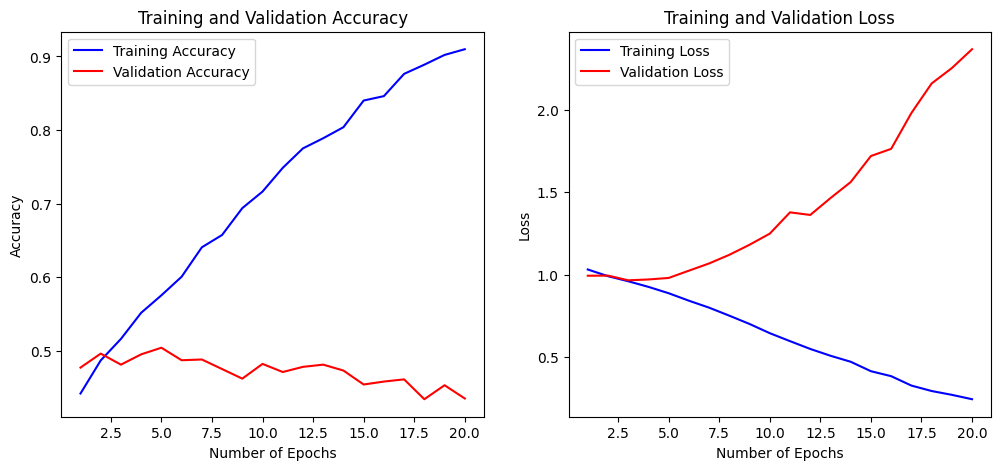

In [37]:
#Revisar Accuracy & Loss
plot_accuracy_loss(history_hp_ann_2l)

In [38]:
#Evaluar ANN
y_pred_hp_ann_2l = hp_model_ann_2l.predict(X_test) > threshold
print('F1 Score (Weighted)', round(f1_score(y_test, y_pred_hp_ann_2l, average='weighted'),3))
print('F1 Score (por Clase)', f1_score(y_test, y_pred_hp_ann_2l, average=None))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
F1 Score (Weighted) 0.452
F1 Score (por Clase) [0.5015873  0.32183908 0.44444444]
